# DA-6 — Time-Series Analysis and Forecasting of Reported Crime Incidents
## Complete 100-Mark Version — Two Official Datasets

This notebook is designed from the instructor-provided Experiment 06 format and covers the full assessed workflow:

**Dataset provenance → data validation → regular weekly time series → chronological train/validation/test split → EDA → ADF → ACF/PACF → naive baseline → AR → multiple ARIMA candidates → validation-based order selection → locked test evaluation → MAE/RMSE → residual diagnostics → Ljung-Box → rolling-origin validation → prediction intervals → second dataset replication → interpretation → responsible analytics → reproducibility artifacts.**

### Two official datasets

**Dataset 1 — Chicago Crimes: 2001 to Present**  
https://data.cityofchicago.org/Public-Safety/Crimes-2001-to-Present/ijzp-q8t2

**Dataset 2 — NYPD Complaint Data Historic**  
https://data.cityofnewyork.us/Public-Safety/NYPD-Complaint-Data-Historic/qgea-i56i

The notebook defaults to **DEMO mode**, which uses synthetic data shaped like the two datasets. This lets the entire notebook be tested without downloading either large dataset. Change `DATA_MODE` to `LIVE` only when ready to query the official APIs.


In [1]:
# 1. Imports and setup
# If needed in a fresh environment:
# !pip -q install pandas numpy matplotlib statsmodels scikit-learn requests

from pathlib import Path
import json, platform, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

OUT = Path("lab06_outputs")
FIG = OUT / "figures"
OUT.mkdir(exist_ok=True)
FIG.mkdir(exist_ok=True)

print("Python:", sys.version.split()[0])
print("Output:", OUT.resolve())


Python: 3.13.5
Output: /mnt/data/DA6_GitHub_Ready/lab06_outputs


In [2]:
# 2. Configuration
DATA_MODE = "DEMO"       # "DEMO" for testing; change to "LIVE" for official APIs

START_DATE = "2020-01-01"
END_DATE = "2025-12-31"

# Chicago core location: police district
CHICAGO_CORE_LOCATION = "001"

# NYPD replication location: borough
NYPD_CORE_LOCATION = "MANHATTAN"

FREQUENCY = "W-MON"
TEST_PERIODS = 12
VALIDATION_PERIODS = 12
AR_LAGS = 4

ARIMA_CANDIDATES = [
    (1,0,0),
    (2,0,0),
    (1,1,1),
    (2,1,1)
]

CHICAGO_SOURCE = "https://data.cityofchicago.org/Public-Safety/Crimes-2001-to-Present/ijzp-q8t2"
CHICAGO_API = "https://data.cityofchicago.org/resource/ijzp-q8t2.json"

NYPD_SOURCE = "https://data.cityofnewyork.us/Public-Safety/NYPD-Complaint-Data-Historic/qgea-i56i"
NYPD_API = "https://data.cityofnewyork.us/resource/qgea-i56i.json"

print("Mode:", DATA_MODE)
print("Chicago:", CHICAGO_SOURCE)
print("NYPD:", NYPD_SOURCE)


Mode: DEMO
Chicago: https://data.cityofchicago.org/Public-Safety/Crimes-2001-to-Present/ijzp-q8t2
NYPD: https://data.cityofnewyork.us/Public-Safety/NYPD-Complaint-Data-Historic/qgea-i56i


## 1. Dataset provenance and governance

### Chicago
The official Chicago Crimes dataset is the preferred core dataset in the instructor format. For the time series, the relevant fields are the incident date and police district.

### NYPD
The official NYPD Complaint Data Historic dataset is used as the second dataset. For replication, complaint date and borough are used to construct an aggregate weekly complaint-count series.

### Responsible use
Both datasets contain records of reported/recorded incidents or complaints. Forecasts therefore describe reporting/recording patterns, not actual crime prevalence, individual dangerousness, guilt, or future offending. Aggregate forecasts must not be interpreted as person-level risk scores.


In [3]:
# 3. Helper functions
def score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(mean_squared_error(y_true, y_pred) ** 0.5)
    }

def weekly_series(data, date_col, location_col, location, freq=FREQUENCY):
    x = data[data[location_col].astype(str).str.upper() == str(location).upper()].copy()
    if x.empty:
        raise ValueError(f"No rows found for location {location}.")
    x[date_col] = pd.to_datetime(x[date_col], errors="coerce")
    x = x.dropna(subset=[date_col])
    y = (
        x.set_index(date_col)
         .resample(freq)
         .size()
         .asfreq(freq, fill_value=0)
         .astype(float)
    )
    assert y.index.is_monotonic_increasing
    assert y.index.is_unique
    assert y.isna().sum() == 0
    return y

def split_series(y):
    H = TEST_PERIODS
    V = VALIDATION_PERIODS
    assert len(y) > H + V + 30
    test = y.iloc[-H:]
    pretest = y.iloc[:-H]
    validation = pretest.iloc[-V:]
    train = pretest.iloc[:-V]
    assert train.index.max() < validation.index.min() < test.index.min()
    return train, validation, pretest, test

def fit_arima_candidates(train, validation):
    rows = []
    models = {}
    for order in ARIMA_CANDIDATES:
        try:
            m = ARIMA(train, order=order).fit()
            pv = m.forecast(len(validation))
            sc = score(validation, pv)
            rows.append({
                "order": str(order),
                "AIC": float(m.aic),
                "BIC": float(m.bic),
                "Validation_MAE": sc["MAE"],
                "Validation_RMSE": sc["RMSE"],
                "status": "ok"
            })
            models[order] = m
        except Exception as e:
            rows.append({
                "order": str(order),
                "AIC": np.nan,
                "BIC": np.nan,
                "Validation_MAE": np.nan,
                "Validation_RMSE": np.nan,
                "status": f"failed: {e}"
            })
    table = pd.DataFrame(rows)
    valid = table[table.status == "ok"].copy()
    assert len(valid) >= 3, "At least three ARIMA candidates must fit."
    best_str = valid.sort_values(
        ["Validation_MAE","Validation_RMSE","AIC"]
    ).iloc[0]["order"]
    best = tuple(int(v.strip()) for v in best_str.strip("()").split(","))
    return table, best

def rolling_validation(series, order, initial=None, horizon=8, step=8):
    if initial is None:
        initial = max(52, len(series)//2)
    rows=[]
    end=initial
    fold=1
    while end+horizon <= len(series):
        tr=series.iloc[:end]
        te=series.iloc[end:end+horizon]
        try:
            m=ARIMA(tr, order=order).fit()
            pr=m.forecast(horizon)
            sc=score(te,pr)
            rows.append({"fold":fold, **sc})
        except Exception:
            pass
        end += step
        fold += 1
    return pd.DataFrame(rows)


In [4]:
# 4. DEMO data generator — no real dataset is downloaded
def make_demo_dataset(start, end, locations, bases, seed=42):
    rng = np.random.default_rng(seed)
    dates = pd.date_range(start, end, freq="D")
    rows=[]
    for loc, base in zip(locations, bases):
        t=np.arange(len(dates))
        seasonal=1 + 0.15*np.sin(2*np.pi*t/365.25) + 0.08*np.sin(2*np.pi*t/7)
        trend=1 + 0.0001*t
        lam=np.maximum(base*seasonal*trend, 0.2)
        counts=rng.poisson(lam)
        for d,c in zip(dates,counts):
            for _ in range(int(c)):
                rows.append({"date":d, "location":loc})
    return pd.DataFrame(rows)

if DATA_MODE.upper() == "DEMO":
    chicago_raw = make_demo_dataset(
        START_DATE, END_DATE, ["001","002"], [22,18], SEED
    )
    nypd_raw = make_demo_dataset(
        START_DATE, END_DATE, ["MANHATTAN","BROOKLYN"], [35,28], SEED+1
    )
    print("DEMO mode: synthetic incident/complaint rows generated.")
    print("Chicago rows:", len(chicago_raw))
    print("NYPD rows:", len(nypd_raw))


DEMO mode: synthetic incident/complaint rows generated.
Chicago rows: 97021
NYPD rows: 153746


## 2. Live API acquisition

When `DATA_MODE = "LIVE"`, only the required date/location fields are queried. The notebook does **not** ask the user to download the full multi-million-row CSV.

For Chicago, the API uses:
- `date`
- `district`

For NYPD Historic, the API uses:
- `cmplnt_fr_dt`
- `boro_nm`

If the live API is slow or the instructor supplies a filtered CSV/parquet extract, use that extract instead and set the corresponding loading cell accordingly.


In [5]:
# 5. Live API paginated loaders
def get_socrata_pages(api, params_base, limit=50000, max_rows=500000):
    rows=[]
    offset=0
    while len(rows) < max_rows:
        params=dict(params_base)
        params["$limit"]=min(limit, max_rows-len(rows))
        params["$offset"]=offset
        r=requests.get(api, params=params, timeout=120)
        r.raise_for_status()
        batch=r.json()
        if not batch:
            break
        rows.extend(batch)
        print(f"Retrieved {len(rows):,} rows")
        if len(batch) < params["$limit"]:
            break
        offset += len(batch)
    return pd.DataFrame(rows)

if DATA_MODE.upper() == "LIVE":
    chicago_params = {
        "$select":"date,district",
        "$where":(
            f"date >= '{START_DATE}T00:00:00' AND "
            f"date < '{pd.Timestamp(END_DATE)+pd.Timedelta(days=1):%Y-%m-%d}T00:00:00' "
            "AND district IS NOT NULL"
        )
    }
    nypd_params = {
        "$select":"cmplnt_fr_dt,boro_nm",
        "$where":(
            f"cmplnt_fr_dt >= '{START_DATE}T00:00:00' AND "
            f"cmplnt_fr_dt < '{pd.Timestamp(END_DATE)+pd.Timedelta(days=1):%Y-%m-%d}T00:00:00' "
            "AND boro_nm IS NOT NULL"
        )
    }

    chicago_raw = get_socrata_pages(CHICAGO_API, chicago_params)
    nypd_raw = get_socrata_pages(NYPD_API, nypd_params)

    print("Chicago live rows:", len(chicago_raw))
    print("NYPD live rows:", len(nypd_raw))


In [6]:
# 6. Standardize both datasets into the same analysis structure
if DATA_MODE.upper() == "DEMO":
    chicago = chicago_raw.rename(columns={"date":"event_date","location":"location"})[
        ["event_date","location"]
    ].copy()
    nypd = nypd_raw.rename(columns={"date":"event_date","location":"location"})[
        ["event_date","location"]
    ].copy()
else:
    chicago = chicago_raw.rename(columns={
        "date":"event_date",
        "district":"location"
    })[["event_date","location"]].copy()

    nypd = nypd_raw.rename(columns={
        "cmplnt_fr_dt":"event_date",
        "boro_nm":"location"
    })[["event_date","location"]].copy()

for name, data in [("Chicago",chicago),("NYPD",nypd)]:
    data["event_date"]=pd.to_datetime(data["event_date"],errors="coerce")
    data["location"]=data["location"].astype(str).str.strip()
    data.dropna(subset=["event_date","location"], inplace=True)
    print(name, "date range:", data.event_date.min(), "to", data.event_date.max())
    print(name, "rows:", len(data))


Chicago date range: 2020-01-01 00:00:00 to 2025-12-31 00:00:00
Chicago rows: 97021
NYPD date range: 2020-01-01 00:00:00 to 2025-12-31 00:00:00
NYPD rows: 153746


# DATASET 1 — CHICAGO CORE ANALYSIS


In [7]:
# 7. Chicago regular weekly series
chi_y = weekly_series(
    chicago, "event_date", "location", CHICAGO_CORE_LOCATION
)

print("Chicago core district:", CHICAGO_CORE_LOCATION)
print("Weekly periods:", len(chi_y))
print(chi_y.describe())


Chicago core district: 001
Weekly periods: 314
count    314.000000
mean     169.780255
std       24.131551
min       50.000000
25%      154.000000
50%      169.000000
75%      186.000000
max      230.000000
dtype: float64


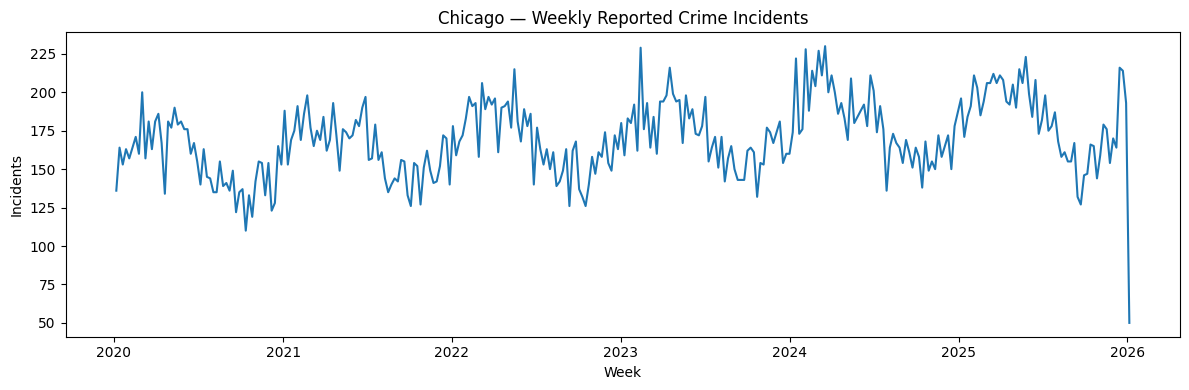

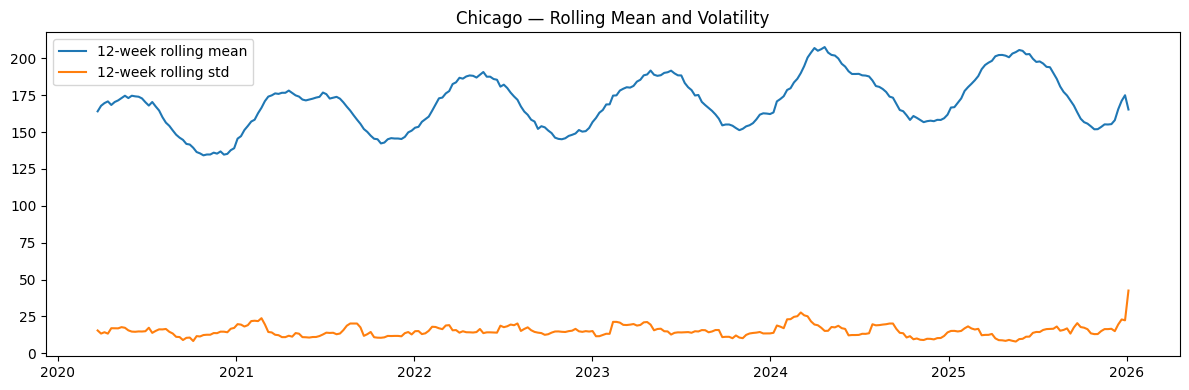

In [8]:
# 8. Chicago EDA
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(chi_y.index, chi_y.values)
ax.set_title("Chicago — Weekly Reported Crime Incidents")
ax.set_xlabel("Week")
ax.set_ylabel("Incidents")
plt.tight_layout()
plt.savefig(FIG/"01_chicago_weekly_series.png",dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(chi_y.index, chi_y.rolling(12).mean(), label="12-week rolling mean")
ax.plot(chi_y.index, chi_y.rolling(12).std(), label="12-week rolling std")
ax.set_title("Chicago — Rolling Mean and Volatility")
ax.legend()
plt.tight_layout()
plt.savefig(FIG/"02_chicago_rolling_stats.png",dpi=160)
plt.show()


In [9]:
# 9. Chicago chronological split
chi_train, chi_val, chi_pretest, chi_test = split_series(chi_y)
print("Train:", chi_train.index.min(), "to", chi_train.index.max(), len(chi_train))
print("Validation:", chi_val.index.min(), "to", chi_val.index.max(), len(chi_val))
print("Locked test:", chi_test.index.min(), "to", chi_test.index.max(), len(chi_test))


Train: 2020-01-06 00:00:00 to 2025-07-21 00:00:00 290
Validation: 2025-07-28 00:00:00 to 2025-10-13 00:00:00 12
Locked test: 2025-10-20 00:00:00 to 2026-01-05 00:00:00 12


In [10]:
# 10. Chicago naive baseline
chi_naive_val=np.repeat(chi_train.iloc[-1],len(chi_val))
chi_naive_test=np.repeat(chi_pretest.iloc[-1],len(chi_test))
print("Chicago naive validation:",score(chi_val,chi_naive_val))
print("Chicago naive test:",score(chi_test,chi_naive_test))


Chicago naive validation: {'MAE': 23.75, 'RMSE': 27.225906780123964}
Chicago naive test: {'MAE': 26.0, 'RMSE': 40.779897008207364}


In [11]:
# 11. Chicago ADF
chi_adf=adfuller(chi_train)
print("ADF statistic:",round(chi_adf[0],4))
print("ADF p-value:",round(chi_adf[1],6))


ADF statistic: -4.8976
ADF p-value: 3.5e-05


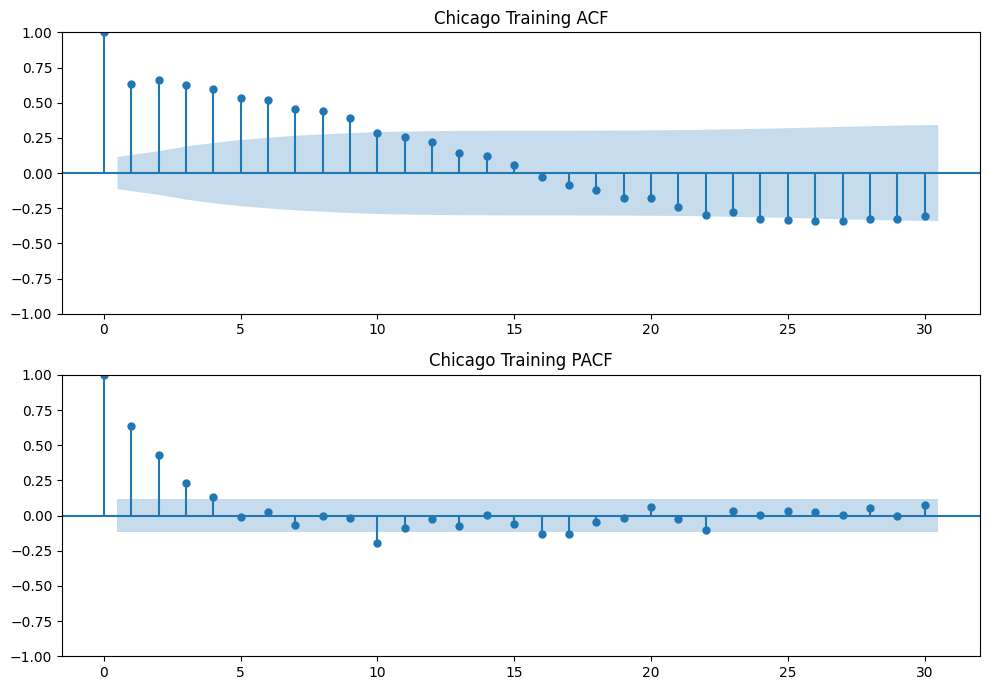

In [12]:
# 12. Chicago ACF/PACF
lags=min(30,max(5,len(chi_train)//4))
fig,axes=plt.subplots(2,1,figsize=(10,7))
plot_acf(chi_train,lags=lags,ax=axes[0])
plot_pacf(chi_train,lags=lags,ax=axes[1],method="ywm")
axes[0].set_title("Chicago Training ACF")
axes[1].set_title("Chicago Training PACF")
plt.tight_layout()
plt.savefig(FIG/"03_chicago_acf_pacf.png",dpi=160)
plt.show()


In [13]:
# 13. Chicago AR(4)
chi_ar=AutoReg(chi_train,lags=AR_LAGS,old_names=False,trend="ct").fit()
chi_ar_val=chi_ar.predict(
    start=len(chi_train),
    end=len(chi_train)+len(chi_val)-1,
    dynamic=False
)
chi_ar_final=AutoReg(chi_pretest,lags=AR_LAGS,old_names=False,trend="ct").fit()
chi_ar_test=chi_ar_final.predict(
    start=len(chi_pretest),
    end=len(chi_pretest)+len(chi_test)-1,
    dynamic=False
)
print("Chicago AR validation:",score(chi_val,chi_ar_val))
print("Chicago AR test:",score(chi_test,chi_ar_test))


Chicago AR validation: {'MAE': 28.789831197100387, 'RMSE': 32.469072849814516}
Chicago AR test: {'MAE': 25.963150056316096, 'RMSE': 41.15940363265308}


In [14]:
# 14. Chicago ARIMA candidate comparison and selection
chi_candidates, chi_best=fit_arima_candidates(chi_train,chi_val)
print("Selected Chicago ARIMA:",chi_best)
display(chi_candidates)
chi_candidates.to_csv(OUT/"chicago_arima_candidates.csv",index=False)


Selected Chicago ARIMA: (1, 0, 0)


,order,AIC,BIC,Validation_MAE,Validation_RMSE,status
0,"(1, 0, 0)",2502.248975,2513.258618,17.706681,21.538524,ok
1,"(2, 0, 0)",2445.155706,2459.835230,19.182508,22.754038,ok
2,"(1, 1, 1)",2423.589077,2434.588357,26.470519,30.007896,ok
3,"(2, 1, 1)",2424.934947,2439.600654,26.251583,29.837352,ok


In [15]:
# 15. Chicago locked-test ARIMA
chi_arima=ARIMA(chi_pretest,order=chi_best).fit()
chi_arima_test=chi_arima.forecast(len(chi_test))

chi_results=pd.DataFrame([
    {"Dataset":"Chicago","Model":"Naive",**score(chi_test,chi_naive_test)},
    {"Dataset":"Chicago","Model":f"AR({AR_LAGS})",**score(chi_test,chi_ar_test)},
    {"Dataset":"Chicago","Model":f"ARIMA{chi_best}",**score(chi_test,chi_arima_test)}
]).sort_values("MAE")

display(chi_results)
chi_results.to_csv(OUT/"chicago_model_comparison.csv",index=False)


,Dataset,Model,MAE,RMSE
2,Chicago,"ARIMA(1, 0, 0)",25.66970,40.910815
1,Chicago,AR(4),25.96315,41.159404
0,Chicago,Naive,26.00000,40.779897


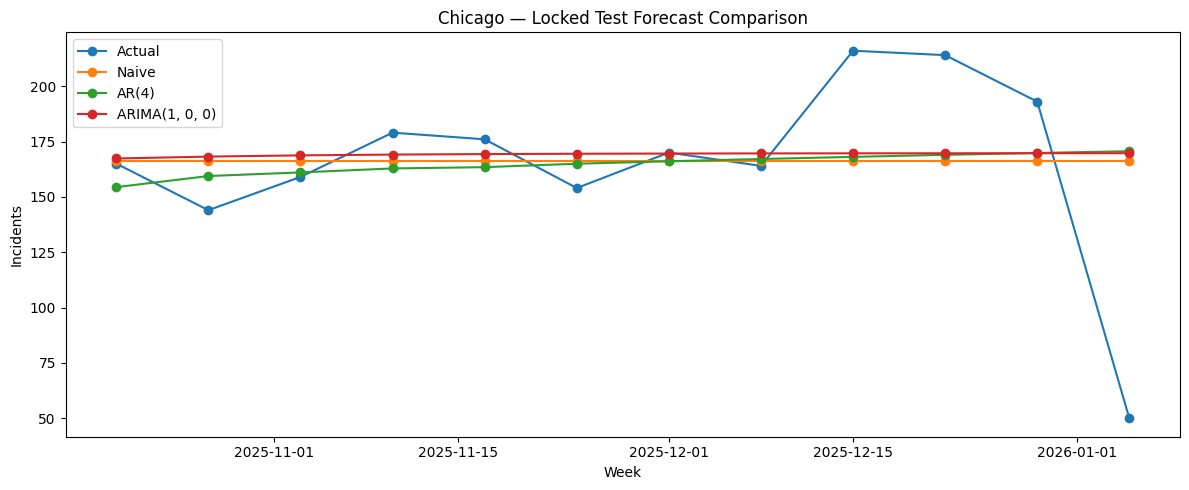

In [16]:
# 16. Chicago actual vs forecasts
fig,ax=plt.subplots(figsize=(12,5))
ax.plot(chi_test.index,chi_test.values,marker="o",label="Actual")
ax.plot(chi_test.index,chi_naive_test,marker="o",label="Naive")
ax.plot(chi_test.index,chi_ar_test,marker="o",label=f"AR({AR_LAGS})")
ax.plot(chi_test.index,chi_arima_test,marker="o",label=f"ARIMA{chi_best}")
ax.set_title("Chicago — Locked Test Forecast Comparison")
ax.set_xlabel("Week")
ax.set_ylabel("Incidents")
ax.legend()
plt.tight_layout()
plt.savefig(FIG/"04_chicago_test_forecasts.png",dpi=160)
plt.show()


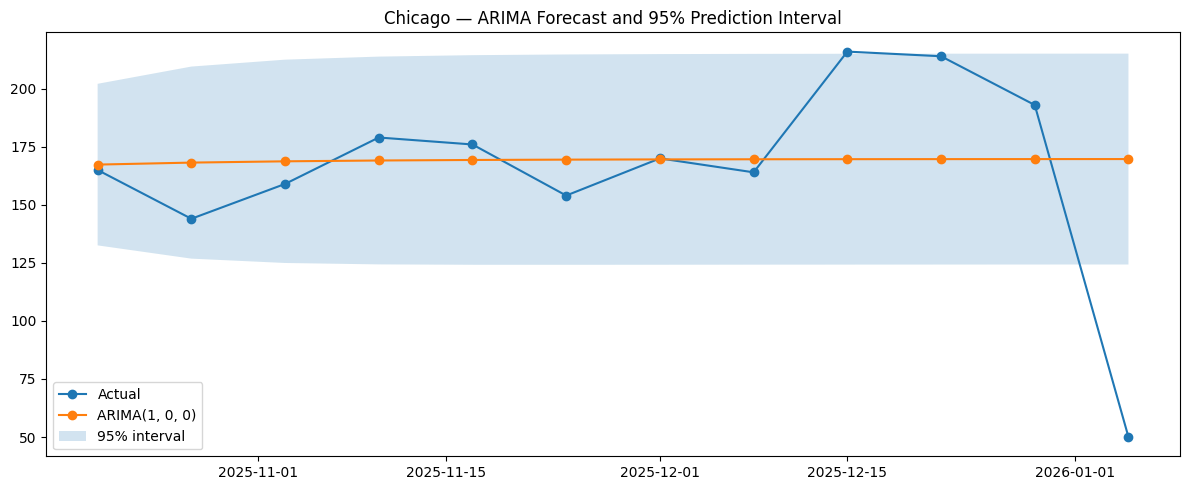

Chicago empirical interval coverage: 0.833


In [17]:
# 17. Chicago prediction intervals
chi_fc=chi_arima.get_forecast(len(chi_test))
chi_mean=chi_fc.predicted_mean
chi_ci=chi_fc.conf_int(alpha=0.05)

fig,ax=plt.subplots(figsize=(12,5))
ax.plot(chi_test.index,chi_test.values,marker="o",label="Actual")
ax.plot(chi_test.index,chi_mean.values,marker="o",label=f"ARIMA{chi_best}")
ax.fill_between(chi_test.index,chi_ci.iloc[:,0],chi_ci.iloc[:,1],alpha=.2,label="95% interval")
ax.set_title("Chicago — ARIMA Forecast and 95% Prediction Interval")
ax.legend()
plt.tight_layout()
plt.savefig(FIG/"05_chicago_prediction_intervals.png",dpi=160)
plt.show()

chi_interval_coverage=np.mean(
    (chi_test.values>=chi_ci.iloc[:,0].values)&
    (chi_test.values<=chi_ci.iloc[:,1].values)
)
print("Chicago empirical interval coverage:",round(float(chi_interval_coverage),3))


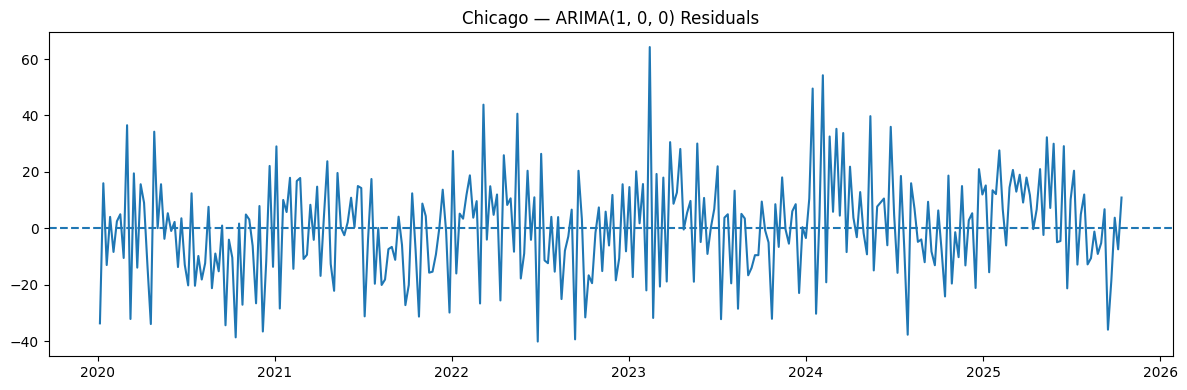

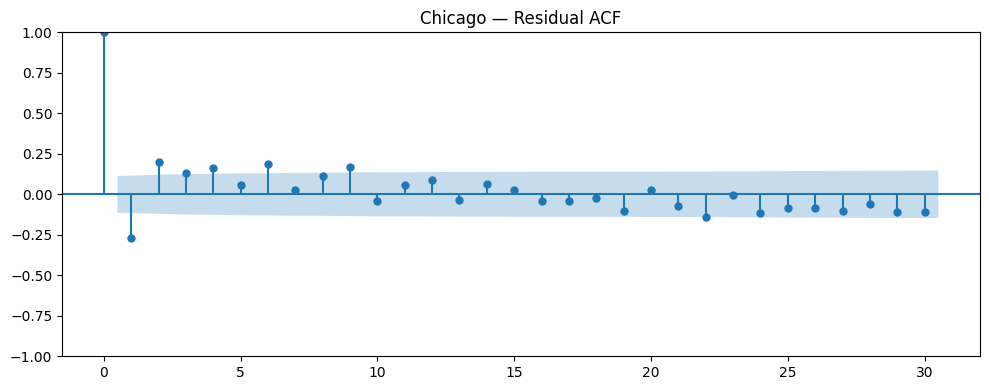

,lb_stat,lb_pvalue
10,73.291867,1.021965e-11


In [18]:
# 18. Chicago residual diagnostics
chi_resid=chi_arima.resid.dropna()

fig,ax=plt.subplots(figsize=(12,4))
ax.plot(chi_resid.index,chi_resid.values)
ax.axhline(0,linestyle="--")
ax.set_title(f"Chicago — ARIMA{chi_best} Residuals")
plt.tight_layout()
plt.savefig(FIG/"06_chicago_residuals.png",dpi=160)
plt.show()

fig,ax=plt.subplots(figsize=(10,4))
plot_acf(chi_resid,lags=min(30,max(5,len(chi_resid)//4)),ax=ax)
ax.set_title("Chicago — Residual ACF")
plt.tight_layout()
plt.savefig(FIG/"07_chicago_residual_acf.png",dpi=160)
plt.show()

chi_lb_lag=min(10,max(2,len(chi_resid)//10))
chi_lb=acorr_ljungbox(chi_resid,lags=[chi_lb_lag],return_df=True)
display(chi_lb)


In [19]:
# 19. Chicago rolling-origin validation
chi_roll=rolling_validation(
    chi_pretest,
    chi_best,
    horizon=min(8,VALIDATION_PERIODS),
    step=min(8,VALIDATION_PERIODS)
)
display(chi_roll)
print("Chicago rolling mean MAE:",chi_roll.MAE.mean())
print("Chicago rolling mean RMSE:",chi_roll.RMSE.mean())
chi_roll.to_csv(OUT/"chicago_rolling_validation.csv",index=False)


,fold,MAE,RMSE
0,1,10.982494,12.882895
1,2,20.606432,28.236346
2,3,31.224523,32.770403
3,4,16.320830,18.287448
4,5,11.973921,15.604350
5,6,15.131074,18.587105
6,7,10.439301,11.856719
7,8,22.700316,32.506694
8,9,43.487874,44.863718
9,10,14.194088,18.198077


Chicago rolling mean MAE: 18.888737734365222
Chicago rolling mean RMSE: 21.975628416310546


# DATASET 2 — NYPD REPLICATION


In [20]:
# 20. NYPD regular weekly series
nypd_y=weekly_series(
    nypd,"event_date","location",NYPD_CORE_LOCATION
)

print("NYPD borough:",NYPD_CORE_LOCATION)
print("Weekly periods:",len(nypd_y))
print(nypd_y.describe())


NYPD borough: MANHATTAN
Weekly periods: 314
count    314.000000
mean     273.076433
std       37.779593
min       63.000000
25%      247.000000
50%      272.000000
75%      300.750000
max      392.000000
dtype: float64


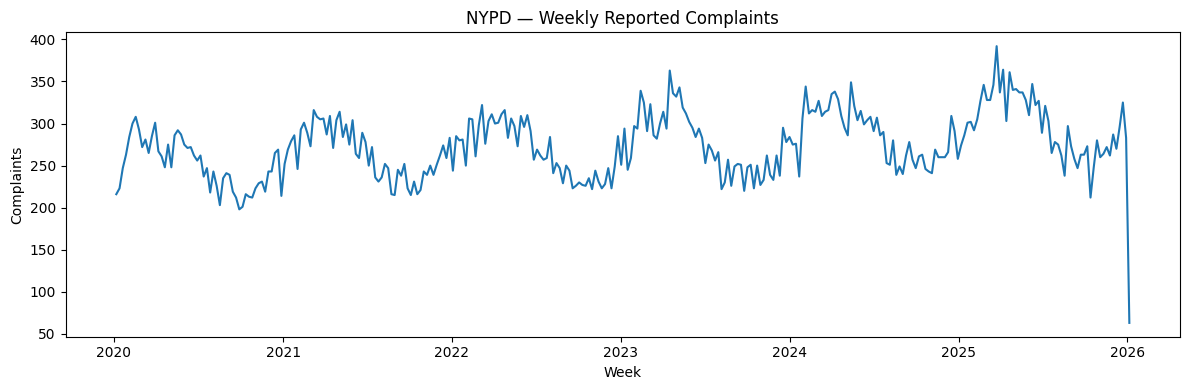

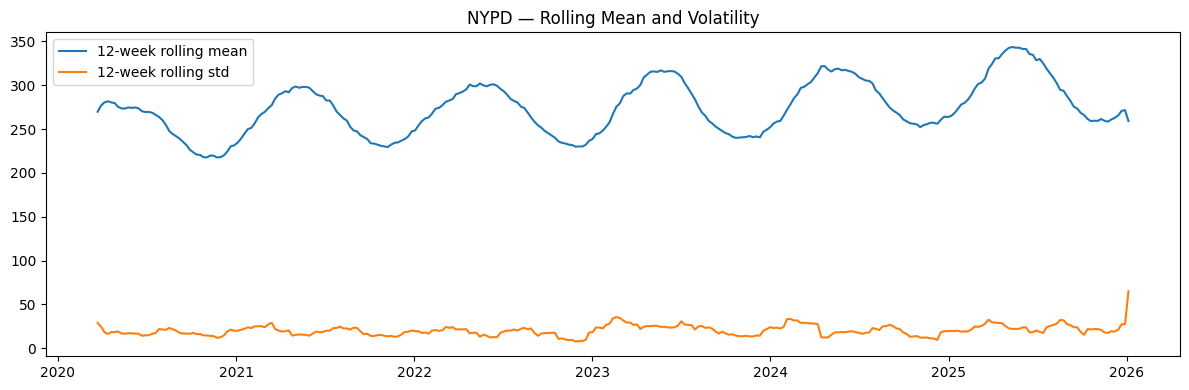

In [21]:
# 21. NYPD EDA
fig,ax=plt.subplots(figsize=(12,4))
ax.plot(nypd_y.index,nypd_y.values)
ax.set_title("NYPD — Weekly Reported Complaints")
ax.set_xlabel("Week")
ax.set_ylabel("Complaints")
plt.tight_layout()
plt.savefig(FIG/"08_nypd_weekly_series.png",dpi=160)
plt.show()

fig,ax=plt.subplots(figsize=(12,4))
ax.plot(nypd_y.index,nypd_y.rolling(12).mean(),label="12-week rolling mean")
ax.plot(nypd_y.index,nypd_y.rolling(12).std(),label="12-week rolling std")
ax.set_title("NYPD — Rolling Mean and Volatility")
ax.legend()
plt.tight_layout()
plt.savefig(FIG/"09_nypd_rolling_stats.png",dpi=160)
plt.show()


In [22]:
# 22. NYPD chronological split and naive baseline
ny_train,ny_val,ny_pretest,ny_test=split_series(nypd_y)
ny_naive_val=np.repeat(ny_train.iloc[-1],len(ny_val))
ny_naive_test=np.repeat(ny_pretest.iloc[-1],len(ny_test))

print("NYPD train:",ny_train.index.min(),"to",ny_train.index.max())
print("NYPD validation:",ny_val.index.min(),"to",ny_val.index.max())
print("NYPD locked test:",ny_test.index.min(),"to",ny_test.index.max())
print("NYPD naive test:",score(ny_test,ny_naive_test))


NYPD train: 2020-01-06 00:00:00 to 2025-07-21 00:00:00
NYPD validation: 2025-07-28 00:00:00 to 2025-10-13 00:00:00
NYPD locked test: 2025-10-20 00:00:00 to 2026-01-05 00:00:00
NYPD naive test: {'MAE': 72.0, 'RMSE': 78.04058773057346}


NYPD ADF statistic: -6.2167
NYPD ADF p-value: 0.0


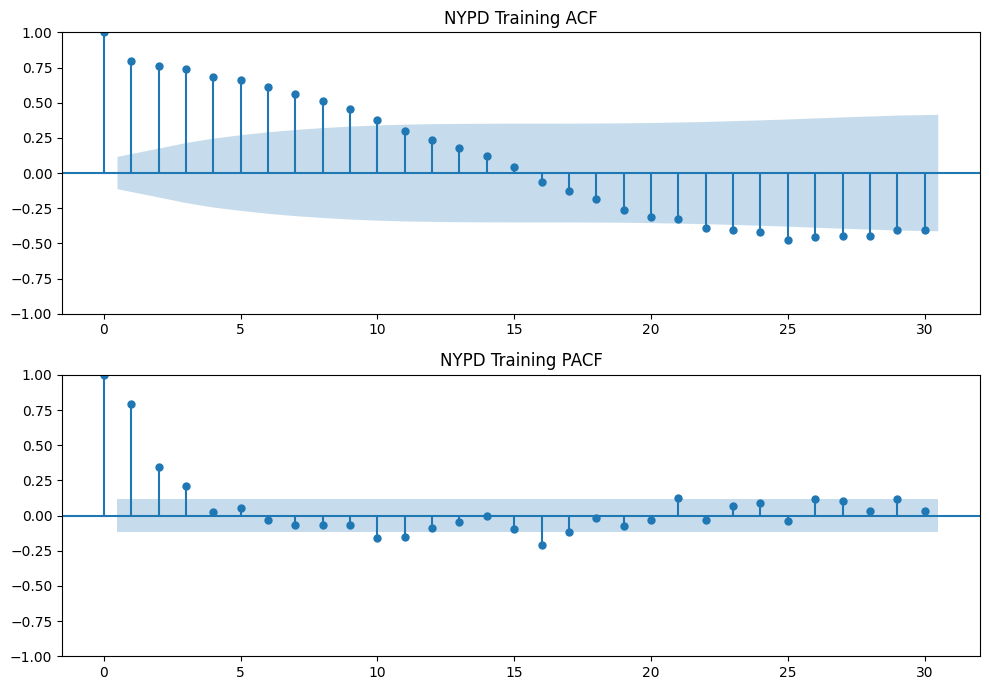

In [23]:
# 23. NYPD ADF + ACF/PACF
ny_adf=adfuller(ny_train)
print("NYPD ADF statistic:",round(ny_adf[0],4))
print("NYPD ADF p-value:",round(ny_adf[1],6))

lags=min(30,max(5,len(ny_train)//4))
fig,axes=plt.subplots(2,1,figsize=(10,7))
plot_acf(ny_train,lags=lags,ax=axes[0])
plot_pacf(ny_train,lags=lags,ax=axes[1],method="ywm")
axes[0].set_title("NYPD Training ACF")
axes[1].set_title("NYPD Training PACF")
plt.tight_layout()
plt.savefig(FIG/"10_nypd_acf_pacf.png",dpi=160)
plt.show()


In [24]:
# 24. NYPD AR(4)
ny_ar=AutoReg(ny_train,lags=AR_LAGS,old_names=False,trend="ct").fit()
ny_ar_val=ny_ar.predict(start=len(ny_train),end=len(ny_train)+len(ny_val)-1,dynamic=False)
ny_ar_final=AutoReg(ny_pretest,lags=AR_LAGS,old_names=False,trend="ct").fit()
ny_ar_test=ny_ar_final.predict(start=len(ny_pretest),end=len(ny_pretest)+len(ny_test)-1,dynamic=False)

print("NYPD AR validation:",score(ny_val,ny_ar_val))
print("NYPD AR test:",score(ny_test,ny_ar_test))


NYPD AR validation: {'MAE': 30.036656714703174, 'RMSE': 35.981029209346744}
NYPD AR test: {'MAE': 37.69560376808086, 'RMSE': 64.06386425626589}


In [25]:
# 25. NYPD ARIMA candidate comparison and selection
ny_candidates,ny_best=fit_arima_candidates(ny_train,ny_val)
print("Selected NYPD ARIMA:",ny_best)
display(ny_candidates)
ny_candidates.to_csv(OUT/"nypd_arima_candidates.csv",index=False)


Selected NYPD ARIMA: (2, 0, 0)


,order,AIC,BIC,Validation_MAE,Validation_RMSE,status
0,"(1, 0, 0)",2624.733643,2635.743286,16.965772,23.442627,ok
1,"(2, 0, 0)",2587.882496,2602.562020,16.911605,24.155317,ok
2,"(1, 1, 1)",2571.916426,2582.915707,26.757445,32.473423,ok
3,"(2, 1, 1)",2571.911372,2586.577079,26.204916,31.804477,ok


In [26]:
# 26. NYPD locked-test results
ny_arima=ARIMA(ny_pretest,order=ny_best).fit()
ny_arima_test=ny_arima.forecast(len(ny_test))

ny_results=pd.DataFrame([
    {"Dataset":"NYPD","Model":"Naive",**score(ny_test,ny_naive_test)},
    {"Dataset":"NYPD","Model":f"AR({AR_LAGS})",**score(ny_test,ny_ar_test)},
    {"Dataset":"NYPD","Model":f"ARIMA{ny_best}",**score(ny_test,ny_arima_test)}
]).sort_values("MAE")

display(ny_results)
ny_results.to_csv(OUT/"nypd_model_comparison.csv",index=False)


,Dataset,Model,MAE,RMSE
1,NYPD,AR(4),37.695604,64.063864
2,NYPD,"ARIMA(2, 0, 0)",42.996229,65.017437
0,NYPD,Naive,72.000000,78.040588


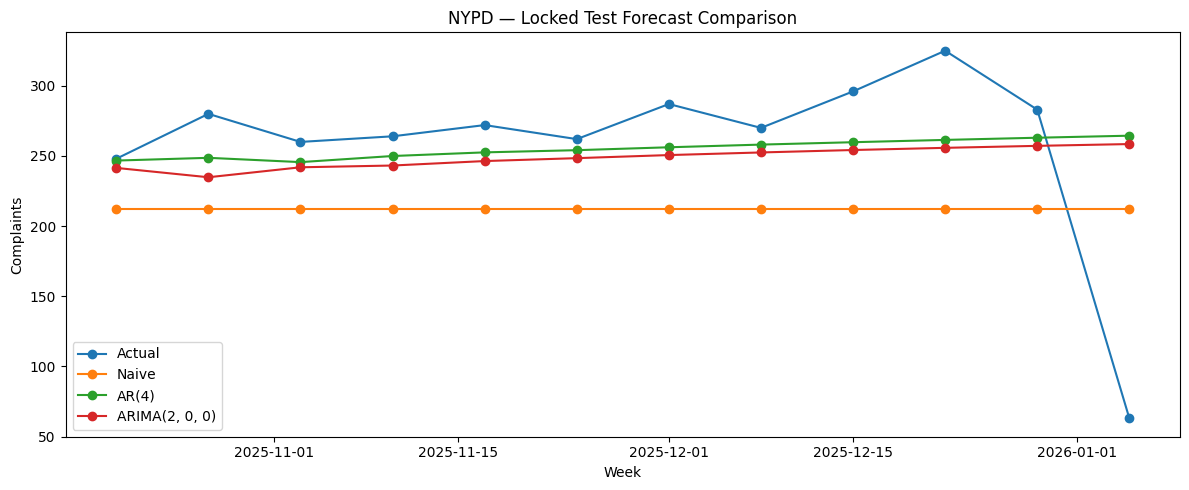

In [27]:
# 27. NYPD actual vs forecasts
fig,ax=plt.subplots(figsize=(12,5))
ax.plot(ny_test.index,ny_test.values,marker="o",label="Actual")
ax.plot(ny_test.index,ny_naive_test,marker="o",label="Naive")
ax.plot(ny_test.index,ny_ar_test,marker="o",label=f"AR({AR_LAGS})")
ax.plot(ny_test.index,ny_arima_test,marker="o",label=f"ARIMA{ny_best}")
ax.set_title("NYPD — Locked Test Forecast Comparison")
ax.set_xlabel("Week")
ax.set_ylabel("Complaints")
ax.legend()
plt.tight_layout()
plt.savefig(FIG/"11_nypd_test_forecasts.png",dpi=160)
plt.show()


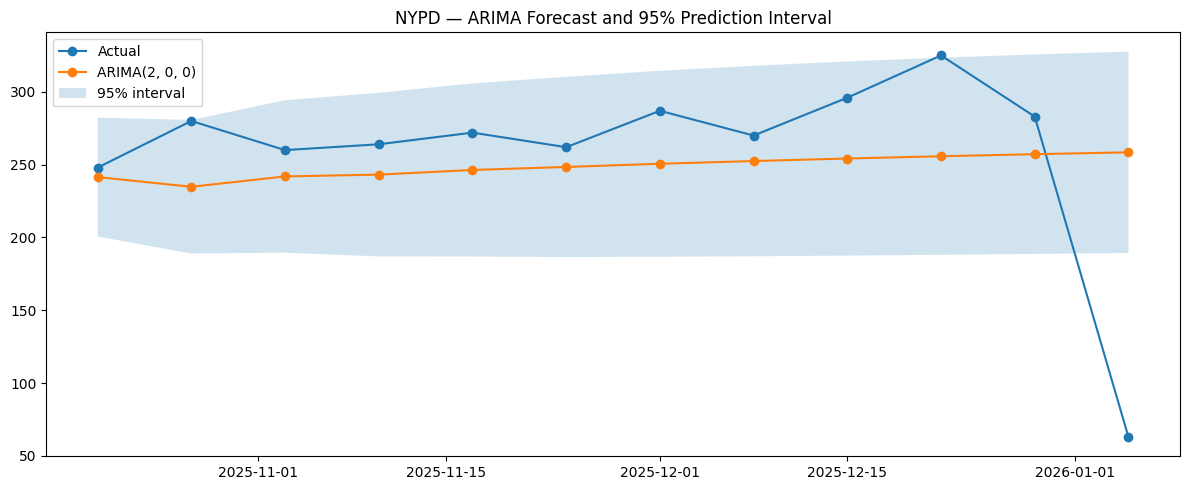

NYPD empirical interval coverage: 0.833


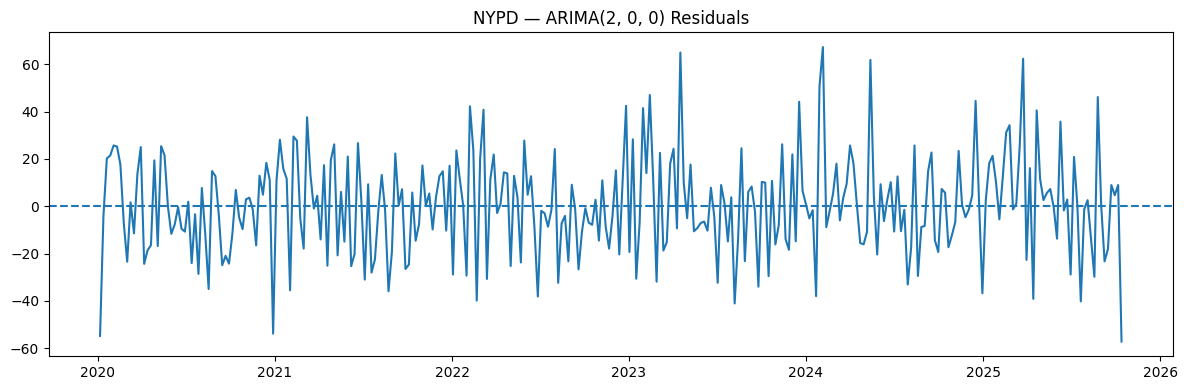

,lb_stat,lb_pvalue
10,21.520802,0.017741


In [28]:
# 28. NYPD prediction intervals and residual diagnostics
ny_fc=ny_arima.get_forecast(len(ny_test))
ny_mean=ny_fc.predicted_mean
ny_ci=ny_fc.conf_int(alpha=.05)

fig,ax=plt.subplots(figsize=(12,5))
ax.plot(ny_test.index,ny_test.values,marker="o",label="Actual")
ax.plot(ny_test.index,ny_mean.values,marker="o",label=f"ARIMA{ny_best}")
ax.fill_between(ny_test.index,ny_ci.iloc[:,0],ny_ci.iloc[:,1],alpha=.2,label="95% interval")
ax.set_title("NYPD — ARIMA Forecast and 95% Prediction Interval")
ax.legend()
plt.tight_layout()
plt.savefig(FIG/"12_nypd_prediction_intervals.png",dpi=160)
plt.show()

ny_interval_coverage=np.mean(
    (ny_test.values>=ny_ci.iloc[:,0].values)&
    (ny_test.values<=ny_ci.iloc[:,1].values)
)
print("NYPD empirical interval coverage:",round(float(ny_interval_coverage),3))

ny_resid=ny_arima.resid.dropna()
fig,ax=plt.subplots(figsize=(12,4))
ax.plot(ny_resid.index,ny_resid.values)
ax.axhline(0,linestyle="--")
ax.set_title(f"NYPD — ARIMA{ny_best} Residuals")
plt.tight_layout()
plt.savefig(FIG/"13_nypd_residuals.png",dpi=160)
plt.show()

ny_lb_lag=min(10,max(2,len(ny_resid)//10))
ny_lb=acorr_ljungbox(ny_resid,lags=[ny_lb_lag],return_df=True)
display(ny_lb)


In [29]:
# 29. NYPD rolling-origin validation
ny_roll=rolling_validation(
    ny_pretest,
    ny_best,
    horizon=min(8,VALIDATION_PERIODS),
    step=min(8,VALIDATION_PERIODS)
)
display(ny_roll)
print("NYPD rolling mean MAE:",ny_roll.MAE.mean())
print("NYPD rolling mean RMSE:",ny_roll.RMSE.mean())
ny_roll.to_csv(OUT/"nypd_rolling_validation.csv",index=False)


,fold,MAE,RMSE
0,1,18.143884,25.198955
1,2,43.755681,49.443693
2,3,41.668880,49.378132
3,4,20.096118,22.723446
4,5,18.025939,23.307660
5,6,10.438583,14.313639
6,7,17.413293,19.642458
7,8,25.941777,35.245777
8,9,23.442478,29.002079
9,10,18.071768,21.564557


NYPD rolling mean MAE: 22.552513067885442
NYPD rolling mean RMSE: 27.16320750575089


# 30. Cross-dataset comparison and interpretation

The two datasets are intentionally analyzed with the same forecasting protocol while respecting their different geographic fields:

- **Chicago:** police district `001`
- **NYPD:** borough `MANHATTAN`
- Weekly frequency: `W-MON`
- Same chronological holdout size
- Same validation-based ARIMA candidate selection
- Same MAE/RMSE evaluation
- Same residual diagnostics
- Same rolling-origin procedure

This makes the second dataset a replication/extension rather than a direct comparison of crime levels. The raw counts are not directly comparable because the jurisdictions, populations, reporting systems, definitions and geographic units differ.


In [30]:
# 31. Combined model comparison
all_results=pd.concat([chi_results,ny_results],ignore_index=True)
display(all_results.sort_values(["Dataset","MAE"]))
all_results.to_csv(OUT/"two_dataset_model_comparison.csv",index=False)

print("\nBest model by MAE within each dataset:")
display(all_results.loc[all_results.groupby("Dataset")["MAE"].idxmin()])


,Dataset,Model,MAE,RMSE
0,Chicago,"ARIMA(1, 0, 0)",25.669700,40.910815
1,Chicago,AR(4),25.963150,41.159404
2,Chicago,Naive,26.000000,40.779897
3,NYPD,AR(4),37.695604,64.063864
4,NYPD,"ARIMA(2, 0, 0)",42.996229,65.017437
5,NYPD,Naive,72.000000,78.040588



Best model by MAE within each dataset:


,Dataset,Model,MAE,RMSE
0,Chicago,"ARIMA(1, 0, 0)",25.669700,40.910815
3,NYPD,AR(4),37.695604,64.063864


In [31]:
# 32. Final reproducibility checks
assert chi_y.index.is_monotonic_increasing and chi_y.index.is_unique
assert nypd_y.index.is_monotonic_increasing and nypd_y.index.is_unique
assert len(chi_test)==TEST_PERIODS and len(ny_test)==TEST_PERIODS
assert chi_train.index.max()<chi_val.index.min()<chi_test.index.min()
assert ny_train.index.max()<ny_val.index.min()<ny_test.index.min()
assert len(chi_candidates)>=3 and len(ny_candidates)>=3
assert (OUT/"two_dataset_model_comparison.csv").exists()

print("All core reproducibility checks passed.")


All core reproducibility checks passed.


In [32]:
# 33. Save experiment manifest
manifest={
    "data_mode":DATA_MODE,
    "datasets":{
        "Chicago":{
            "source":CHICAGO_SOURCE,
            "api":CHICAGO_API,
            "location_field":"district",
            "date_field":"date",
            "location":CHICAGO_CORE_LOCATION
        },
        "NYPD":{
            "source":NYPD_SOURCE,
            "api":NYPD_API,
            "location_field":"boro_nm",
            "date_field":"cmplnt_fr_dt",
            "location":NYPD_CORE_LOCATION
        }
    },
    "date_window":[START_DATE,END_DATE],
    "frequency":FREQUENCY,
    "test_periods":TEST_PERIODS,
    "validation_periods":VALIDATION_PERIODS,
    "ar_lags":AR_LAGS,
    "arima_candidates":ARIMA_CANDIDATES,
    "selected_arima":{
        "Chicago":list(chi_best),
        "NYPD":list(ny_best)
    },
    "adf":{
        "Chicago":{"statistic":float(chi_adf[0]),"p_value":float(chi_adf[1])},
        "NYPD":{"statistic":float(ny_adf[0]),"p_value":float(ny_adf[1])}
    },
    "ljung_box":{
        "Chicago":{"lag":int(chi_lb_lag),"p_value":float(chi_lb["lb_pvalue"].iloc[0])},
        "NYPD":{"lag":int(ny_lb_lag),"p_value":float(ny_lb["lb_pvalue"].iloc[0])}
    },
    "python":sys.version,
    "platform":platform.platform()
}
(OUT/"manifest.json").write_text(json.dumps(manifest,indent=2,default=str),encoding="utf-8")
print(json.dumps(manifest,indent=2,default=str))


{
  "data_mode": "DEMO",
  "datasets": {
    "Chicago": {
      "source": "https://data.cityofchicago.org/Public-Safety/Crimes-2001-to-Present/ijzp-q8t2",
      "api": "https://data.cityofchicago.org/resource/ijzp-q8t2.json",
      "location_field": "district",
      "date_field": "date",
      "location": "001"
    },
    "NYPD": {
      "source": "https://data.cityofnewyork.us/Public-Safety/NYPD-Complaint-Data-Historic/qgea-i56i",
      "api": "https://data.cityofnewyork.us/resource/qgea-i56i.json",
      "location_field": "boro_nm",
      "date_field": "cmplnt_fr_dt",
      "location": "MANHATTAN"
    }
  },
  "date_window": [
    "2020-01-01",
    "2025-12-31"
  ],
  "frequency": "W-MON",
  "test_periods": 12,
  "validation_periods": 12,
  "ar_lags": 4,
  "arima_candidates": [
    [
      1,
      0,
      0
    ],
    [
      2,
      0,
      0
    ],
    [
      1,
      1,
      1
    ],
    [
      2,
      1,
      1
    ]
  ],
  "selected_arima": {
    "Chicago": [
      1,


# 34. Final 100-Mark Checklist

Before submission, verify that the final report/notebook contains:

- [x] Problem framing and target definition
- [x] Dataset provenance and governance
- [x] **Two official datasets**
- [x] Date and location fields documented
- [x] Regular weekly time-series construction
- [x] Chronological train/validation/test split
- [x] Leakage prevention
- [x] EDA and time-series plots
- [x] Rolling mean / volatility exploration
- [x] ADF stationarity test
- [x] ACF and PACF
- [x] Naive baseline
- [x] AR model
- [x] At least three ARIMA candidates
- [x] Validation-based ARIMA order selection
- [x] Locked final test evaluation
- [x] MAE and RMSE
- [x] Actual-vs-forecast plots
- [x] Prediction intervals
- [x] Residual time plot
- [x] Residual ACF
- [x] Ljung-Box test
- [x] Rolling-origin / walk-forward validation
- [x] Second dataset replication
- [x] Cross-location/dataset interpretation
- [x] Responsible analytics and limitations
- [x] Reproducibility checks
- [x] Manifest and CSV artifacts
- [x] Figures saved to an output folder

## Important before submission

**DEMO mode is only for testing the notebook.** Do not submit synthetic results as your DA results.

For the final run, use:

```python
DATA_MODE = "LIVE"
```

or use the filtered files supplied/approved by your instructor. Then replace the numerical results in your written discussion with the actual results generated from the real datasets.
